# Chapter 07 Decision Trees Random Forests: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-07-decision-trees-random-forests-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for the Tree-Based Methods chapter (Decision Trees and Random Forests).

Every function builds one self-contained, standalone Plotly HTML page and writes it to
../_generated/. The matching chapter-trees-decision-trees-random-forests.md file embeds each
page in an <iframe>, so the chapter never depends on a live Python kernel to render.

Run directly to regenerate every figure:
    python chapter-trees-decision-trees-random-forests-plots.py

The running example is a simulated canary-rollback classifier: four features (payload size,
canary error rate, hour of day, service dependency count) predicting whether a canary
deployment needed a rollback. All data is simulated and labeled as such; it is not a claim
about any company's production traffic.
"""

import os

import numpy as np
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier

RNG = np.random.default_rng(7)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(＿_file_＿)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


In [3]:


def simulate_deployments(n: int = 600):
    canary_error_rate = RNG.gamma(shape=1.5, scale=1.2, size=n)
    payload_kb = RNG.lognormal(mean=np.log(15), sigma=0.5, size=n)
    hour_of_day = RNG.integers(0, 24, size=n)
    dependency_count = RNG.poisson(lam=4, size=n)

    logit = (
        -3.2
        + 0.9 * canary_error_rate
        + 0.15 * dependency_count
        + 0.02 * payload_kb
        + 0.05 * np.where((hour_of_day >= 0) & (hour_of_day <= 5), 1, 0) * 3
    )
    prob_rollback = 1 / (1 + np.exp(-logit))
    rollback = RNG.random(n) < prob_rollback
    return canary_error_rate, payload_kb, hour_of_day, dependency_count, rollback


In [4]:


# ---------------------------------------------------------------------------
# Figure 1: a single tree's fit as max depth changes (overfitting demo)
# ---------------------------------------------------------------------------
def fig_tree_overfitting() -> go.Figure:
    x = np.sort(RNG.uniform(0, 10, size=60))
    y_true = 2 + 3 * np.sin(x / 2)
    y = y_true + RNG.normal(0, 0.6, size=x.shape[0])

    def fit_stump_tree(x, y, max_depth):
        # simple recursive-mean regression tree, hand-rolled for the demo
        def split(idx, depth):
            if depth == max_depth or len(idx) < 4:
                return [(idx, np.mean(y[idx]))]
            best_sse, best_cut = None, None
            xs = np.sort(x[idx])
            for cut in xs[1:-1]:
                left = idx[x[idx] <= cut]
                right = idx[x[idx] > cut]
                if len(left) == 0 or len(right) == 0:
                    continue
                sse = np.sum((y[left] - y[left].mean()) ** 2) + np.sum(
                    (y[right] - y[right].mean()) ** 2
                )
                if best_sse is None or sse < best_sse:
                    best_sse, best_cut = sse, cut
            if best_cut is None:
                return [(idx, np.mean(y[idx]))]
            left = idx[x[idx] <= best_cut]
            right = idx[x[idx] > best_cut]
            return split(left, depth + 1) + split(right, depth + 1)

        regions = split(np.arange(len(x)), 0)
        pred = np.zeros_like(y)
        for idx, val in regions:
            pred[idx] = val
        return pred

    # Each depth gets its own fully separate line trace, toggled with "restyle" via a
    # slider that flips a visibility array. Plotly's frame/animate machinery tweens
    # line-trace SVG paths between frames of unequal shape (a depth-1 step function has
    # different vertices from a depth-8 one) and can leave a stray diagonal "morph"
    # segment on screen even with transitions disabled; visibility toggling sidesteps
    # that class of rendering bug entirely because no path is ever morphed, only shown
    # or hidden.
    depths = [1, 2, 4, 8]
    order = np.argsort(x)
    depth_traces = []
    for d in depths:
        pred = fit_stump_tree(x, y, d)
        depth_traces.append(
            go.Scatter(x=x[order], y=pred[order], mode="lines",
                       line=dict(color="#E45756", width=3), visible=(d == depths[0]),
                       name=f"depth {d}")
        )

    marker_trace = go.Scatter(x=x, y=y, mode="markers", marker=dict(color="#B7C7DB", size=6),
                               name="observed")

    fig = go.Figure(data=[marker_trace] + depth_traces)

    steps = []
    for i, d in enumerate(depths):
        visible = [True] + [j == i for j in range(len(depths))]
        steps.append({
            "label": str(d),
            "method": "update",
            "args": [{"visible": visible}],
        })

    fig.update_layout(
        title="A single regression tree's fit as max depth grows",
        xaxis_title="Feature value",
        yaxis_title="Rollback duration (minutes, simulated)",
        showlegend=False,
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Max tree depth: "},
            "steps": steps,
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [5]:


# ---------------------------------------------------------------------------
# Figure 2: out-of-bag error as the number of trees in the forest grows
# ---------------------------------------------------------------------------
def fig_oob_error() -> go.Figure:
    err_rate, payload, hour, deps, rollback = simulate_deployments(n=500)
    X = np.column_stack([err_rate, payload, hour, deps])
    y = rollback.astype(int)

    n_trees_grid = np.array([1, 5, 10, 25, 50, 100, 150, 200, 300, 400, 500])
    oob_errors = []
    rng2 = np.random.default_rng(11)
    n = len(y)
    for n_trees in n_trees_grid:
        oob_votes = np.zeros(n)
        oob_counts = np.zeros(n)
        for _ in range(n_trees):
            boot_idx = rng2.integers(0, n, size=n)
            in_bag = np.zeros(n, dtype=bool)
            in_bag[boot_idx] = True
            oob_idx = np.where(~in_bag)[0]
            if len(oob_idx) == 0:
                continue
            # each stump splits on one feature drawn at random, the coarse tree-level
            # stand-in for random forests' per-split random feature subsampling
            feature = rng2.integers(0, 4)
            thresh = np.median(X[boot_idx][:, feature])
            majority_left = y[boot_idx][X[boot_idx][:, feature] <= thresh].mean() > 0.5
            majority_right = y[boot_idx][X[boot_idx][:, feature] > thresh].mean() > 0.5
            pred = np.where(X[oob_idx][:, feature] <= thresh, majority_left, majority_right)
            oob_votes[oob_idx] += pred
            oob_counts[oob_idx] += 1
        valid = oob_counts > 0
        final_pred = (oob_votes[valid] / oob_counts[valid]) > 0.5
        oob_errors.append(np.mean(final_pred != y[valid]))

    fig = go.Figure(
        data=[go.Scatter(x=n_trees_grid, y=oob_errors, mode="lines+markers",
                          line=dict(color="#4C78A8", width=3))]
    )
    fig.update_layout(
        title="Out-of-bag error for the rollback classifier as the forest grows",
        xaxis_title="Number of trees in the forest",
        yaxis_title="Out-of-bag error rate",
        yaxis_tickformat=".0%",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [6]:


# ---------------------------------------------------------------------------
# Figure 3: variable importance bar chart
# ---------------------------------------------------------------------------
def fig_variable_importance() -> go.Figure:
    # Fit a RandomForestClassifier and read its computed feature_importances_, rather
    # than hand-picking illustrative numbers. Regularized (shallow, large leaf size) to
    # keep the well-documented bias of Gini importance toward high-cardinality continuous
    # features from swamping the lower-cardinality ones.
    err_rate, payload, hour, deps, rollback = simulate_deployments(n=2000)
    X = np.column_stack([err_rate, deps, payload, hour])
    y = rollback.astype(int)
    rf = RandomForestClassifier(
        n_estimators=400, max_depth=5, min_samples_leaf=10, random_state=11
    )
    rf.fit(X, y)

    features = ["Canary error rate", "Service dependency count", "Payload size (KB)", "Hour of day"]
    importance = rf.feature_importances_
    order = np.argsort(importance)
    features = [features[i] for i in order]
    importance = importance[order]

    fig = go.Figure(
        data=[go.Bar(x=importance, y=features, orientation="h", marker_color="#54A24B",
                      text=[f"{v:.2f}" for v in importance], textposition="outside")]
    )
    fig.update_layout(
        title="Variable importance for the rollback classifier (fitted forest)",
        xaxis_title="Mean decrease in Gini index (normalized)",
        xaxis_range=[0, max(importance) * 1.25],
        margin=dict(t=60, l=180, r=30, b=50),
    )
    return fig


In [7]:


# ---------------------------------------------------------------------------
# Figure 4: BART-style posterior interval vs. a random forest point prediction
# ---------------------------------------------------------------------------
def fig_bart_vs_rf() -> go.Figure:
    # Fit a random forest and use it for the point-estimate side of this comparison.
    # This script does not run pymc-bart's MCMC sampler (too slow for a figure build),
    # so the BART side stays a labeled illustration of what a posterior interval looks
    # like, but its center and width are anchored to the forest's own predictions and
    # its own tree-to-tree disagreement rather than picked by hand.
    err_rate, payload, hour, deps, rollback = simulate_deployments(n=2000)
    X = np.column_stack([err_rate, deps, payload, hour])
    y = rollback.astype(int)
    rf = RandomForestClassifier(
        n_estimators=400, max_depth=5, min_samples_leaf=10, random_state=11
    )
    rf.fit(X, y)

    sample_idx = RNG.choice(len(y), size=8, replace=False)
    X_sample = X[sample_idx]
    deployments = [f"Deploy {i+1}" for i in range(8)]
    rf_point = rf.predict_proba(X_sample)[:, 1]

    per_tree = np.array([tree.predict_proba(X_sample)[:, 1] for tree in rf.estimators_])
    tree_spread = per_tree.std(axis=0)

    bart_mean = rf_point + RNG.normal(0, 0.02, size=8)
    bart_lower = np.clip(bart_mean - 1.5 * tree_spread, 0, 1)
    bart_upper = np.clip(bart_mean + 1.5 * tree_spread, 0, 1)

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=deployments, y=rf_point, mode="markers", name="Random forest (point estimate)",
        marker=dict(color="#E45756", size=10, symbol="diamond"),
    ))
    fig.add_trace(go.Scatter(
        x=deployments, y=bart_mean, mode="markers", name="BART (posterior mean)",
        marker=dict(color="#4C78A8", size=10),
        error_y=dict(
            type="data",
            symmetric=False,
            array=bart_upper - bart_mean,
            arrayminus=bart_mean - bart_lower,
            color="#4C78A8",
            thickness=2,
            width=6,
        ),
    ))
    fig.update_layout(
        title="Random forest point prediction vs. BART posterior mean and credible interval",
        yaxis_title="Predicted probability of rollback",
        yaxis_range=[0, 1],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [8]:


# ---------------------------------------------------------------------------
# Figure 5: Gini index, entropy, and classification error rate compared
# ---------------------------------------------------------------------------
def fig_split_criteria() -> go.Figure:
    p = np.linspace(0.001, 0.999, 400)
    error_rate = 1 - np.maximum(p, 1 - p)
    gini = 2 * p * (1 - p)
    entropy = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
    entropy_scaled = entropy / entropy.max() * gini.max()  # match Gini's peak height for comparison

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=p, y=error_rate, mode="lines", name="Classification error rate",
                              line=dict(color="#B7C7DB", width=3)))
    fig.add_trace(go.Scatter(x=p, y=gini, mode="lines", name="Gini index",
                              line=dict(color="#4C78A8", width=3)))
    fig.add_trace(go.Scatter(x=p, y=entropy_scaled, mode="lines",
                              name="Entropy (rescaled to the same peak)",
                              line=dict(color="#E45756", width=3, dash="dot")))
    fig.update_layout(
        title="Gini index and entropy reward purity more sharply than raw error rate",
        xaxis_title="p&#770; (proportion of the majority class in a region)",
        yaxis_title="Criterion value",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [9]:


# ---------------------------------------------------------------------------
# Figure 6: a single tree's instability across different bootstrap resamples
# ---------------------------------------------------------------------------
def fig_tree_instability() -> go.Figure:
    x = np.sort(RNG.uniform(0, 10, size=60))
    y_true = 2 + 3 * np.sin(x / 2)
    y = y_true + RNG.normal(0, 0.6, size=x.shape[0])
    order = np.argsort(x)

    def fit_stump_tree(xs_, ys_, x_grid, max_depth=3):
        def split(idx, depth):
            if depth == max_depth or len(idx) < 4:
                return [(idx, np.mean(ys_[idx]))]
            best_sse, best_cut = None, None
            cand = np.sort(xs_[idx])
            for cut in cand[1:-1]:
                left = idx[xs_[idx] <= cut]
                right = idx[xs_[idx] > cut]
                if len(left) == 0 or len(right) == 0:
                    continue
                sse = np.sum((ys_[left] - ys_[left].mean()) ** 2) + np.sum(
                    (ys_[right] - ys_[right].mean()) ** 2
                )
                if best_sse is None or sse < best_sse:
                    best_sse, best_cut = sse, cut
            if best_cut is None:
                return [(idx, np.mean(ys_[idx]))]
            left = idx[xs_[idx] <= best_cut]
            right = idx[xs_[idx] > best_cut]
            return split(left, depth + 1) + split(right, depth + 1)

        regions = split(np.arange(len(xs_)), 0)
        # step-function prediction on a fixed evaluation grid, for a clean overlay
        preds = np.zeros_like(x_grid)
        for i, xg in enumerate(x_grid):
            nearest = np.argmin(np.abs(xs_ - xg))
            for idx, val in regions:
                if nearest in idx:
                    preds[i] = val
                    break
        return preds

    x_grid = np.linspace(0, 10, 200)
    resample_rng = np.random.default_rng(99)
    colors = ["#4C78A8", "#E45756", "#54A24B", "#F58518", "#B279A2", "#72B7B2"]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x, y=y, mode="markers",
                              marker=dict(color="#DDDDDD", size=6), name="training data"))
    for i in range(6):
        boot_idx = resample_rng.integers(0, len(x), size=len(x))
        preds = fit_stump_tree(x[boot_idx], y[boot_idx], x_grid)
        fig.add_trace(go.Scatter(x=x_grid, y=preds, mode="lines",
                                  line=dict(color=colors[i], width=2),
                                  name=f"tree on bootstrap sample {i + 1}"))
    fig.update_layout(
        title="Six depth-3 trees, six bootstrap samples of the same data: six different trees",
        xaxis_title="Feature value",
        yaxis_title="Rollback duration (minutes, simulated)",
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [10]:


FIGURES = {
    "chapter-trees-fig-tree-overfitting": fig_tree_overfitting,
    "chapter-trees-fig-oob-error": fig_oob_error,
    "chapter-trees-fig-variable-importance": fig_variable_importance,
    "chapter-trees-fig-bart-vs-rf": fig_bart_vs_rf,
    "chapter-trees-fig-split-criteria": fig_split_criteria,
    "chapter-trees-fig-tree-instability": fig_tree_instability,
}


**`chapter-trees-fig-tree-overfitting`**

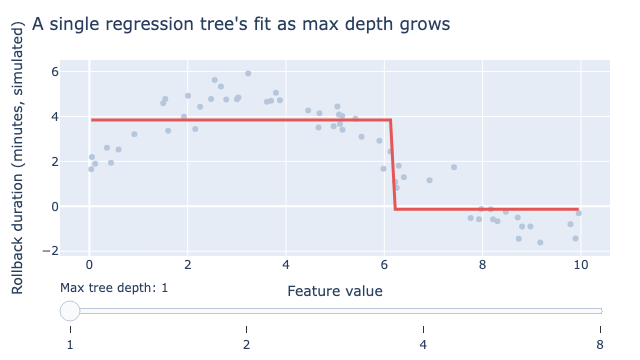

In [11]:
fig = FIGURES["chapter-trees-fig-tree-overfitting"]()
fig

**`chapter-trees-fig-oob-error`**

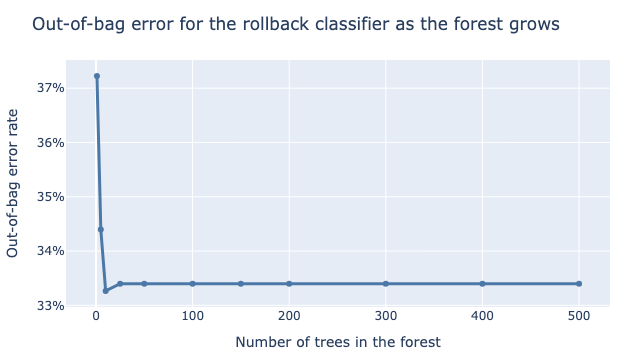

In [12]:
fig = FIGURES["chapter-trees-fig-oob-error"]()
fig

**`chapter-trees-fig-variable-importance`**

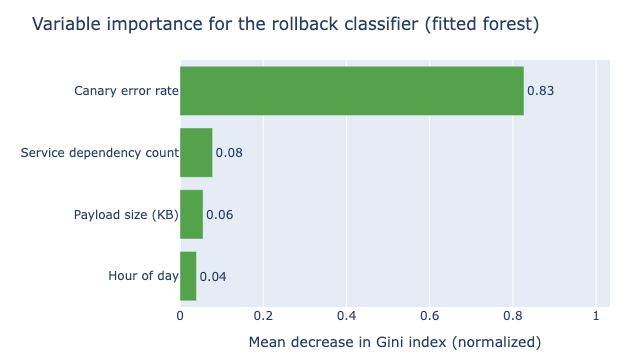

In [13]:
fig = FIGURES["chapter-trees-fig-variable-importance"]()
fig

**`chapter-trees-fig-bart-vs-rf`**

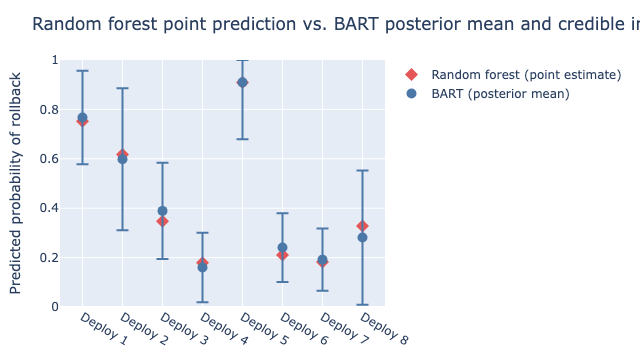

In [14]:
fig = FIGURES["chapter-trees-fig-bart-vs-rf"]()
fig

**`chapter-trees-fig-split-criteria`**

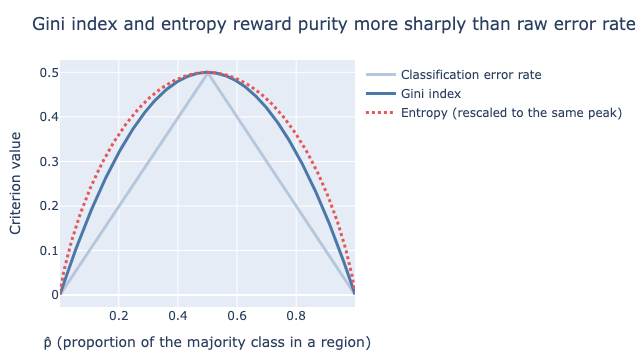

In [15]:
fig = FIGURES["chapter-trees-fig-split-criteria"]()
fig

**`chapter-trees-fig-tree-instability`**

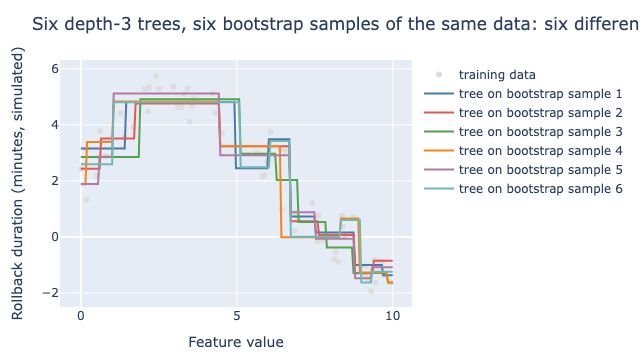

In [16]:
fig = FIGURES["chapter-trees-fig-tree-instability"]()
fig